# **딥러닝 모델링(퀴즈)**

+ 이번시간에는 딥러닝 프로세스에 따라서 실습해 보겠습니다.
+ 물론, 딥러닝의 프로세스는 머신러닝 프로세스와 동일하며, 다만 모델만 다를 뿐이며
+ 데이터 파일 읽기, EDA 데이터 분석, 데이터 전처리, Train, Test 데이터셋 분할, 정규화, 모델 생성 및 학습은 동일합니다. 
+ 딥러닝의 프로세스를 따라 하면서 딥러닝 모델 DNN에 대해 코딩하여 모델 구축해 보겠습니다.
+ 한가지 당부 드리고 싶은 말은 "백문이불여일타" 입니다. 
+ 이론보다 실습이 더 많은 시간과 노력이 투자 되어야 합니다.

### **학습목차**
- 딥러닝 심층신경망(DNN) 모델 프로세스
     - 데이터 가져오기
     - 데이터 전처리
     - Train, Test 데이터셋 분할
     - 데이터 정규화
     - DNN 딥러닝 모델


# 
## **1. 실습을 위한 셋팅 설정**

In [1]:
# 코드실행시 경고 메시지 무시

import warnings
warnings.filterwarnings(action='ignore') 

# 
## **2. 딥러닝 심층신경망(DNN) 모델 프로세스**
① 라이브러리 임포트(import)  
② 데이터 가져오기(Loading the data)  
③ 탐색적 데이터 분석(Exploratory Data Analysis)  
④ 데이터 전처리(Data PreProcessing) : 데이터타입 변환, Null 데이터 처리, 누락데이터 처리, 
더미특성 생성, 특성 추출 (feature engineering) 등  
⑤ Train, Test  데이터셋 분할  
⑥ 데이터 정규화(Normalizing the Data)  
⑦ 모델 개발(Creating the Model)  
⑧ 모델 성능 평가

####
### **① 라이브러리 임포트**

##### 필요 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

####
### **② 데이터 로드**

#### cust_data1.csv 파일 컬럼명
+ 고객등급(class), 성별(sex), 나이(age), 사용서비스수(service), 서비스중지여부 (stop), 미납여부(npay)
+ 3개월 평균 요금(avg_bill), A서비스 3개월 평균요금(A_bill), B서비스 3개월 평균요금(B_bill), 해지여부(termination)

##### <font color=blue> **[문제] 같은 폴더내에 있는 cust_data1.csv 파일을 Pandas read_csv 함수를 이용하여 읽어 df 변수에 저장하세요.** </font>

In [4]:
# 읽어 들일 파일명 : cust_data1.csv
# Pandas read_csv 함수 활용
# 결과 : df 저장
df = pd.read_csv('../cust_data1.csv')



####
### **③ 데이터 분석**

In [5]:
# 10컬럼, 9930 라인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 642.9 KB


In [6]:
df.tail()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
8223,C,M,76.0,1,N,N,1860.0000,1716.000000,0.0000,N
8224,C,F,15.0,1,N,Y,1296.0999,194.414985,643.1001,N
8225,G,M,12.0,1,N,N,13799.6666,2069.949990,10605.9266,N
8226,C,F,40.0,0,N,N,3140.0000,942.000000,1884.0000,Y
8227,C,F,59.0,1,N,N,2436.9000,365.535000,1839.9000,N


##### <font color=blue> **[문제] df DataFrame에 대해서 아래 조건에 맞는 boolean indexing을 하세요.** </font>
- 대상 데이터프레임 : df
- 조건에 맞는 리스트 출력
    - 조건 : 등급(class)이 'C'이고 A요금(A_bill)이 200 이하

In [7]:
# Boolean indexing 검색
# 조건 : 등급(class)이 'C'이고 A요금(A_bill)이 200 이하
# 1. 등급(class) : 'C' >> df[ 'class' ] == 'C' 
# 2. A요금(A_bill) 200 이하 >> df[ 'A_bill' ] <= 200
condition_1 = df['class'] == 'C'
condition_2 = df['A_bill'] <= 200
condition_total = condition_1 & condition_2
df[condition_total]

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
635,C,F,90.0,1,N,N,1324.5000,156.000000,794.70000,N
1785,C,M,25.0,0,N,Y,15857.8666,37.500000,9514.71996,N
1861,C,M,52.0,1,N,N,836.3001,30.000000,281.87850,N
2542,C,M,21.0,1,N,N,300.0000,90.000000,180.00000,Y
2606,C,M,54.0,1,N,N,2200.0000,0.000000,2002.00000,N
...,...,...,...,...,...,...,...,...,...,...
8079,C,M,60.0,1,N,N,2344.8666,0.000000,2146.86660,N
8149,C,F,9.0,1,N,N,4179.3334,0.000000,3981.33340,N
8171,C,F,67.0,1,N,N,3938.1334,0.000000,3740.13340,N
8211,C,M,49.0,1,N,N,2812.8000,0.000000,2614.80000,N


<Axes: xlabel='termination'>

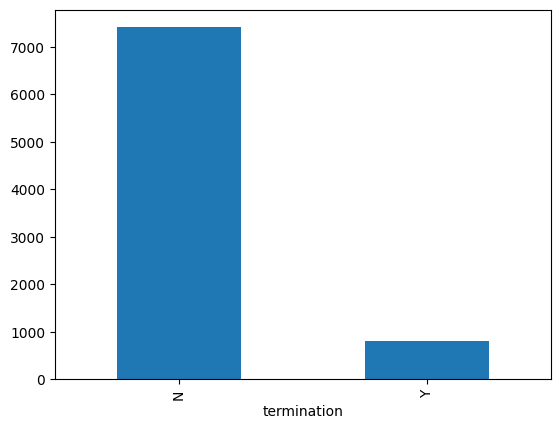

In [8]:
# termination 레이블 불균형 
df['termination'].value_counts().plot(kind='bar')

####
### **④ 데이터 전처리**

In [9]:
# 문자열 데이터 : class , sex, stop, npay, termination
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,Y
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,N
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,N
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,N
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,N


##### <font color=blue> **[문제] replace 함수를 사용해서 'termination' 컬럼을 모델이 이해할수 있도록 Y --> 1 , N--> 0으로 변경하세요** </font>

In [11]:
# 대상 : df 데이터프레임 
# replace 함수 적용 대상 컬럼 : termination
# 방법1 :  replace( 'Y' , 1 ), replace( 'N' , 0 ) 각각 변경 적용
# 방법2 : df[ 'termination' ].replace( ['Y', 'N'] , [1, 0] ) 이렇게 한번에 적용
df['termination'] = df['termination'].map({'N':0, 'Y':1}).astype('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class        8228 non-null   str    
 1   sex          8228 non-null   str    
 2   age          8228 non-null   float64
 3   service      8228 non-null   int64  
 4   stop         8228 non-null   str    
 5   npay         8228 non-null   str    
 6   avg_bill     8228 non-null   float64
 7   A_bill       8228 non-null   float64
 8   B_bill       8228 non-null   float64
 9   termination  8228 non-null   int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 642.9 KB


In [12]:
# termination 컬럼에 대해 replace 함수 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,N,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,N,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,N,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,N,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,N,1361.7999,1173.99990,0.0000,0


In [13]:
# 라벨인코더 임포트
from sklearn.preprocessing import LabelEncoder

##### <font color=blue> **[문제] df DataFrame에서 'npay' 컬럼을 모델이 이해할수 있도록 라벨인코딩하세요.** </font>

In [14]:
# 대상 : df 데이터프레임 
# 라벨인코더 대상 컬럼 : npay
# LabelEncoder() 함수를 le 정의 및 fit_transform 적용
le = LabelEncoder()
df['npay'] = le.fit_transform(df['npay'])

In [15]:
# npay 컬럼에 대해 라벨인코더 적용후 확인
df.head()

,class,sex,age,service,stop,npay,avg_bill,A_bill,B_bill,termination
0,C,F,28.0,0,N,0,2640.0000,792.00000,1584.0000,1
1,E,F,24.0,1,N,0,16840.0000,2526.00000,6983.0000,0
2,F,F,32.0,1,N,0,15544.7334,2331.71001,6750.4666,0
3,D,M,18.0,1,N,0,4700.0000,0.00000,4502.0000,0
4,C,F,78.0,1,N,0,1361.7999,1173.99990,0.0000,0


In [16]:
# 나머지 문자열 컬럼들 
cal_cols = ['class', 'sex', 'stop']

##### <font color=blue> **[문제] 나머지 Object 컬럼에 대해 Pandas get_dummies 함수 활용하여 원핫인코딩하세요.** </font>

In [19]:
# 대상 : df 데이터프레임 
# 원핫인코딩 대상 컬럼 : 'class', 'sex', 'stop'
# Pandas get_dummies 함수 활용
# get_dummies 함수의 옵션으로 가변수 제거하는 drop_first=True 설정
df = pd.get_dummies(data=df, columns=cal_cols, drop_first=True)

In [20]:
# 기존 1개의 class 컬럼이  5개의 class_D, class_E, class_F, class_G, class_H 컬럼으로 원핫인코딩 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8228 entries, 0 to 8227
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8228 non-null   float64
 1   service      8228 non-null   int64  
 2   npay         8228 non-null   int64  
 3   avg_bill     8228 non-null   float64
 4   A_bill       8228 non-null   float64
 5   B_bill       8228 non-null   float64
 6   termination  8228 non-null   int64  
 7   class_D      8228 non-null   bool   
 8   class_E      8228 non-null   bool   
 9   class_F      8228 non-null   bool   
 10  class_G      8228 non-null   bool   
 11  class_H      8228 non-null   bool   
 12  sex_M        8228 non-null   bool   
 13  stop_Y       8228 non-null   bool   
dtypes: bool(7), float64(4), int64(3)
memory usage: 506.3 KB


####
### **⑤ Train, Test  데이터셋 분할**

In [21]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 제외한 나머지 정보를 X에 저장하세요.** </font>

In [22]:
# 대상 : df 데이터프레임 
# DataFrame drop 함수 활용
# 'termination' 컬럼 삭제
# DataFrame에서 values만 X에 저장
X = df.drop('termination', axis=1)

##### <font color=blue> **[문제] df DataFrame에서 'termination' 컬럼을 y로 저장하세요.** </font>

In [23]:
# 대상 : df 데이터프레임
# DataFrame 'termination' 컬럼 사용
# DataFrame에서 values만 y에 저장
y = df['termination']

In [21]:
X.shape, y.shape

((8228, 13), (8228,))

#### Train , Test dataset 나누기

In [24]:
from sklearn.model_selection import train_test_split

##### <font color=blue> **[문제] Train dataset, Test dataset 나누세요.** </font>

In [25]:
# Train dataset, Test dataset 나누기 : train_test_split 함수 사용
# 입력 : X, y 
# Train : Test 비율 = 7: 3  --> test_size=0.3
# y Class 비율에 맞게 나주어 주세요 : stratify=y
# 여러번 수행해도 같은 결과 나오게 고정하기 : random_state=42 
# 결과 : X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [26]:
X_train.shape

(5759, 13)

In [27]:
y_train.shape

(5759,)

####
### **⑥ 데이터 정규화/스케일링(Normalizing/Scaling)**

In [28]:
# 숫자 분포 이루어진 컬럼 확인
df.tail()

,age,service,npay,avg_bill,A_bill,B_bill,termination,class_D,class_E,class_F,class_G,class_H,sex_M,stop_Y
8223,76.0,1,0,1860.0000,1716.000000,0.0000,0,False,False,False,False,False,True,False
8224,15.0,1,1,1296.0999,194.414985,643.1001,0,False,False,False,False,False,False,False
8225,12.0,1,0,13799.6666,2069.949990,10605.9266,0,False,False,False,True,False,True,False
8226,40.0,0,0,3140.0000,942.000000,1884.0000,1,False,False,False,False,False,False,False
8227,59.0,1,0,2436.9000,365.535000,1839.9000,0,False,False,False,False,False,False,False


In [29]:
from sklearn.preprocessing import StandardScaler

##### <font color=blue> **[문제] X_train과 X_test 데이터에 대해서 StandardScaler 적용하세요.** </font>

In [30]:
# StandardScaler 함수를 정의 : ss 저장
# X_train 데이터에 대해서는 fi_transform 적용
# X_test 데이터에 대해서는 transform 적용
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [31]:
X_train[:2]

array([[ 0.77907132,  4.75702764, -0.36253853,  0.28352014,  0.2182524 ,
         0.8080494 , -0.60282636, -0.42526331,  3.23960028, -0.56886182,
        -0.12811595,  0.92679084, -0.1395438 ],
       [ 0.15466498, -1.54054998, -0.36253853, -0.4993926 ,  0.03443346,
        -0.43986501,  1.65885247, -0.42526331, -0.30868006, -0.56886182,
        -0.12811595,  0.92679084, -0.1395438 ]])

#### 
### **⑦ 딥러닝 심층신경망(DNN) 모델 구현**

### 라이브러리 임포트

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

#### 
### 하이퍼파라미터 설정 : batch_size, epochs

In [36]:
batch_size = 16
epochs = 20

#### 
### 모델 입력(features) 갯수 확인

In [33]:
X_train.shape

(5759, 13)

#### 
### 모델 출력(label) 갯수 확인

In [34]:
y_train.shape

(5759,)

#### 
### A. 이진분류 DNN모델 구성 

![hidden Layer](https://github.com/gzone2000/TEMP_TEST/raw/master/hidden_layer1.PNG)
+ [출처] https://subscription.packtpub.com/book/data/9781788995207/1/ch01lvl1sec03/deep-learning-intuition

##### <font color=blue> **[문제] 요구사항대로 Sequential 모델을 만들어 보세요.** </font>

In [35]:
# Sequential() 모델 정의 하고 model로 저장
# input layer는 input_shape=() 옵션을 사용한다.
# 13개 input layer
# unit 4개 hidden layer
# unit 3개 hidden layer 
# 1개 output layser : 이진분류
model = Sequential()
model.add(Dense(4, activation='relu', input_shape=(13,)))
model.add(Dense(3, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/Users/imgyeonglak/Documents/01_career/02_certificate/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-25 13:22:49.610822: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-25 13:22:49.610873: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-25 13:22:49.610883: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-25 13:22:49.610915: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 13:22:49.610935: I tensorflow/core/common_runtime/pluggable_device/pl

#### 
### 모델 확인

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 구성 -  과적합 방지

![dropout](https://github.com/gzone2000/TEMP_TEST/raw/master/dropout.PNG)
+ [출처] https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5

In [37]:
model = Sequential()
model.add(Dense(4, activation='relu', input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(3, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

#### 
### 과적합 방지 모델 확인

In [38]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75 (300.00 B)

 Trainable params: 75 (300.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 컴파일 – 이진 분류 모델

##### <font color=blue> **[문제] 아래 가이드대로 모델 컴파일하세요.** </font>
- 최적화 알고리즘 optimizer : 'adam'
- 로스 함수 : binary_crossentropy
- 메트릭 : accuracy

In [39]:
# 모델 compile
#   최적화 알고리즘 optimizer : 'adam'
#   로스 함수 : binary_crossentropy (1개의 출력으로 2개 분류해야 하므로)
#   메트릭 : accuracy
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

- 모델 컴파일 – 다중 분류 모델 (Y값을 One-Hot-Encoding 한경우) <br>
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy']) 

- 모델 컴파일 – 다중 분류 모델  (Y값을 One-Hot-Encoding 하지 않은 경우) <br>
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

- 모델 컴파일 – 예측 모델
model.compile(optimizer='adam', loss='mse')

#### 
### 모델 학습

##### <font color=blue> **[문제] 요구사항대로 DNN 모델을 학습시키세요.** </font>
+ 모델 이름 : model
+ epoch : 10번
+ batch_size : 10번

In [40]:
# 앞쪽에서 정의된 모델 이름 : model
# Sequential 모델의 fit() 함수 사용
# @인자
### X, y : X_train, y_train
### validation_data=(X_test, y_test)
### epochs 10번
### batch_size 10번
model.fit(X_train, y_train, epochs=10, batch_size=10, validation_data=(X_test, y_test))

Epoch 1/10


2026-04-25 13:26:10.638545: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


576/576 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6802 - loss: 0.7086 - val_accuracy: 0.9000 - val_loss: 0.3770
Epoch 2/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8180 - loss: 0.4557 - val_accuracy: 0.9008 - val_loss: 0.3115
Epoch 3/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8521 - loss: 0.3873 - val_accuracy: 0.9008 - val_loss: 0.2944
Epoch 4/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8727 - loss: 0.3477 - val_accuracy: 0.9008 - val_loss: 0.2803
Epoch 5/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8850 - loss: 0.3171 - val_accuracy: 0.9008 - val_loss: 0.2664
Epoch 6/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8937 - loss: 0.2951 - val_accuracy: 0.9008 - val_loss: 0.2318
Epoch 7/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9177 - loss: 0.2604 - val_accuracy: 0.9060 - val_loss: 0.1997
Epoch 8/10
576/576 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9239 - loss: 0.2480 - val_accuracy: 0.90

#### 
### B. 다중 분류 DNN 구성
+ 13개 input layer
+ unit 5개 hidden layer
+ dropout
+ unit 4개 hidden layer 
+ dropout
+ 2개 output layser : 이진분류

![다중분류](https://github.com/gzone2000/TEMP_TEST/raw/master/hidden_layer2.PNG)
+ [출처] https://www.educba.com/dnn-neural-network/

In [43]:
# 13개 input layer
# unit 5개 hidden layer
# dropout
# unit 4개 hidden layer 
# dropout
# 2개 output layser : 다중분류

model = Sequential()
model.add(Dense(5, activation='relu', input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(4, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

#### 
### 모델 확인

In [44]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104 (416.00 B)

 Trainable params: 104 (416.00 B)

 Non-trainable params: 0 (0.00 B)

#### 
### 모델 컴파일 – 다중 분류 모델

In [45]:
# loss 함수 : sparse_categorical_crossentropy
# 분류 모델 & 2개의 출력 : categorical_crossentropy
# y레이블을 원핫인코딩해야 하므로 sparse_categorical_crossentropy

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy']) 

#### 
### 모델 학습

In [46]:
history = model.fit(X_train, y_train, 
          validation_data=(X_test, y_test),
          epochs=20, 
          batch_size=16)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6854 - loss: 0.7409 - val_accuracy: 0.7963 - val_loss: 0.4437
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8427 - loss: 0.4228 - val_accuracy: 0.9008 - val_loss: 0.3317
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8913 - loss: 0.3339 - val_accuracy: 0.9008 - val_loss: 0.2948
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8976 - loss: 0.3018 - val_accuracy: 0.9008 - val_loss: 0.2736
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9000 - loss: 0.2788 - val_accuracy: 0.9016 - val_loss: 0.2384
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9097 - loss: 0.2538 - val_accuracy: 0.9202 - val_loss: 0.1976
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9274 - loss: 0.2280 - val_accuracy: 0.9421 - val_loss: 0.1699
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9304 - loss: 0.2188 - val_accu

#### 
### Callback : 조기종료, 모델 저장

In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [49]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', 
                           verbose=1, patience=5)

In [50]:
check_point = ModelCheckpoint('best_model.keras', verbose=1,
                              monitor='val_loss', mode='min', 
                              save_best_only=True)

#### 
### 모델 학습

In [51]:
history = model.fit(x=X_train, y=y_train, 
          epochs=50 , batch_size=20,
          validation_data=(X_test, y_test), 
          verbose=1,
          callbacks=[early_stop, check_point])

Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9477 - loss: 0.1821
Epoch 1: val_loss improved from None to 0.13106, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9458 - loss: 0.1803 - val_accuracy: 0.9615 - val_loss: 0.1311
Epoch 2/50
285/288 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9432 - loss: 0.2003
Epoch 2: val_loss improved from 0.13106 to 0.13068, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9441 - loss: 0.1853 - val_accuracy: 0.9615 - val_loss: 0.1307
Epoch 3/50
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9491 - loss: 0.1707
Epoch 3: val_loss improved from 0.13068 to 0.13055, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9446 - loss: 0.1835 - val_accuracy: 0.96

#### 
### 모델 성능 평가

In [53]:
losses = pd.DataFrame(model.history.history)

In [54]:
losses.head()

,accuracy,loss,val_accuracy,val_loss
0,0.945824,0.180349,0.961523,0.131055
1,0.944088,0.185298,0.961523,0.130675
2,0.944608,0.183516,0.961523,0.130553
3,0.941309,0.194170,0.961523,0.132759
4,0.937836,0.197434,0.961523,0.134313


+ 성능 시각화

<Axes: >

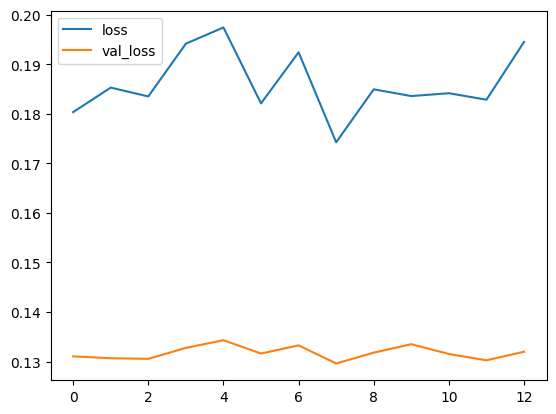

In [55]:
losses[['loss','val_loss']].plot()

<Axes: >

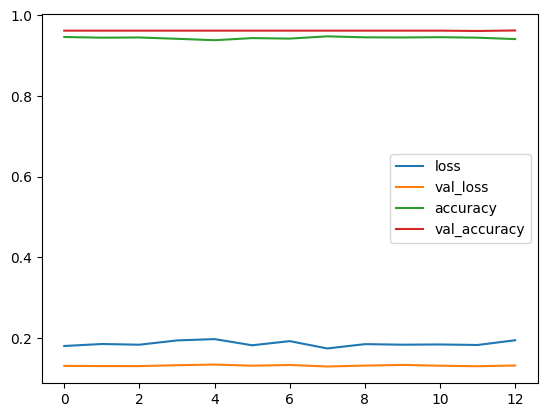

In [56]:
losses[['loss','val_loss', 'accuracy','val_accuracy']].plot()

##### <font color=blue> **[문제] 아래 가이드대로 성능 그래프를 그리세요** </font>
1. matplotlib의 plot 함수를 사용하여 모델의 accuracy와 val_accuracy 그리세요.
2. 타이틀 : Accuracy
3. x레이블 : Epochs
4. y레이블 : Accuracy
5. 범례 표시 : ['accuarcy', 'val_accuarcy']

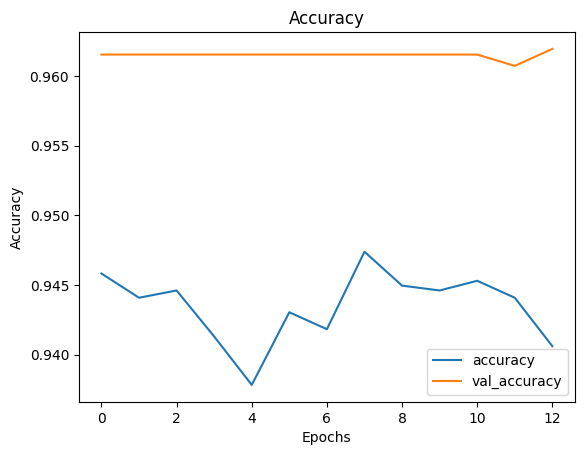

In [ ]:
# matplotlib의 plot 함수를 사용
# 1. 모델의 accuracy와 val_accuracy 성능 --> history.history['accuracy'] , history.history['val_accuracy']
# 2. 타이틀 : Accuracy --> title('Accuracy')
# 3. x레이블 : Epochs --> xlabel('Epochs')
# 4. y레이블 : Accuracy --> ylabel('Accuracy')
# 5. 범례 표시 --> legend(['accuarcy', 'val_accuarcy'])
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()







# 
# **배운 내용 정리**
1. 딥러닝 심층신경망(DNN) 모델 프로세스
 + 데이터 가져오기
 + 데이터 전처리
 + Train, Test 데이터셋 분할
 + 데이터 정규화
 + DNN 딥러닝 모델
